In [1]:
# So, let us dive right in. For convenience, let's begin by enabling
# automatic reloading of modules when they change.
%load_ext autoreload
%autoreload 2

In [2]:
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
# Packages for the simple design
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.qubits.transmon_pocket_teeth import TransmonPocketTeeth
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.qubits.transmon_pocket_6 import TransmonPocket6
from collections import OrderedDict
design = designs.DesignPlanar()
gui = MetalGUI(design)
design.overwrite_enabled = True


In [3]:
design.chips.main.size.size_x = '5mm'
design.chips.main.size.size_y = '5mm'
design.chips.main.size.size_z = '-380um'
design.chips.main.size.sample_holder_top='2mm'
design.chips.main.size.sample_holder_bottom='380um'


In [17]:
OTG1 = OpenToGround(design,name='OTG1'
                 ,options={'pos_x':'-1.1mm','pos_y':'-1.5mm','orientation':'0','width':'15.5um', 'gap':'9um', 'termination_gap': '9um' })


LP1 = LaunchpadWirebondDriven(design,name='LP1',
                       options={'orientation': '0', 'pos_x': '-2.0mm', 'pos_y': '-1.25mm','pad_width':'180um','pad_height':'180um','pad_gap':'140um', 'trace_width':'15.5um' , 'trace_gap': '9um'},
                       component_template={'falseparam1': {'falseparam2': 'false-param', 'falseparam3': 'false-param'}},
                                        )




LP2 = LaunchpadWirebondDriven(design,name='LP2',
                       options={'orientation': '180', 'pos_x': '2.0mm', 'pos_y': '1.25mm','pad_width':'180um','pad_height':'180um','pad_gap':'140um', 'trace_width':'15.5um' , 'trace_gap': '9um'},
                       component_template={'falseparam1': {'falseparam2': 'false-param', 'falseparam3': 'false-param'}},
                                        )

q_read1 = CoupledLineTee(design,'Q_Read1', options=dict(pos_x = '-1.775mm', pos_y = '-0.425mm',
                                                        prime_width='15.5um',
                                                        prime_gap='9um',
                                                        second_width='15.5um',
                                                        second_gap='9um',
                                                        fillet='50um',
                                                        mirror=True,
                                                        orientation = '90',
                                                        coupling_space = '4.5um',                                                         
                                                        coupling_length = '300um',
                                                        open_termination = False))



seg1 = RoutePathfinder(design, 'seg1', options = dict(chip='main', 
                                                      trace_width ='15.5um',
                                                      trace_gap ='9um',
                                                      fillet='100um',
                                                      hfss_wire_bonds = True,
                                                    lead=dict(
                                                        end_straight='0.2mm'),
                                                        pin_inputs=dict(
                                                        start_pin=dict(
                                                                component='Q_Read1',
                                                                pin='prime_start'),
                                                       end_pin=dict(
                                                        component='LP1',
                                                        pin='tie')
                                                 )))



seg2 = RoutePathfinder(design, 'seg2', options = dict(chip='main', 
                                                      trace_width ='15.5um',
                                                      trace_gap ='9um',
                                                      fillet='100um',
                                                      hfss_wire_bonds = True,
                                                    lead=dict(start_straight = '0.125mm',
                                                        end_straight='0.2mm',start_jogged_extension = OrderedDict([(0,['R','0um'])])),
                                                        pin_inputs=dict(
                                                        start_pin=dict(
                                                                component='Q_Read1',
                                                                pin='prime_end'),
                                                       end_pin=dict(
                                                        component='LP2',
                                                        pin='tie')
                                                 )))


RR1 = RouteMeander(design, 'RR1',  Dict(
        trace_width ='15.5um',
        trace_gap ='9um',
        total_length='4mm',
        hfss_wire_bonds = False,
        fillet='50 um',
        lead = dict(start_straight='300um',end_straight='50um'),
        meander= dict(spacing='150um',asymmetry='0um'),
        pin_inputs=Dict(
            start_pin=Dict(component='Q_Read1', pin='second_end'),
            end_pin=Dict(component='OTG1', pin='open')), ))

gui.rebuild()
gui.autoscale()

In [23]:
Q1 = TransmonPocket6(design,'Q1', options = dict(
        pos_x='-0.25mm', 
        pos_y='1.6mm', 
        orientation='180',
        gds_cell_name ='qubit_03',
        hfss_inductance ='10nH',
        pocket_height = '650um',
        pocket_width='650um',
        pad_width='400um',
        pad_height='100um',
        pad_gap='50um',
         connection_pads=dict(
            readout = dict(loc_W=0, loc_H=1, cpw_extend= '100um',
                                             cpw_gap= 'cpw_gap',
                                             cpw_width= 'cpw_width',
                                             pad_cpw_extent= '25um',
                                             pad_cpw_shift='7um',
                                             pad_gap='30um',
                                             pad_height= '30um',
                                             pad_width='50um',
                                             pocket_extent= '5um',
                                             pocket_rise='65um')
        )))

OTG1=OpenToGround(design,name='OTG1'
                 ,options={'pos_x':'-0.45mm','pos_y':'1.6mm','orientation':'0','width':'15.5um', 'gap':'9um',  })



LP1 = LaunchpadWirebondDriven(design,name='LP1',
                       options={'orientation': '0', 'pos_x': '-2.0mm', 'pos_y': '-1.25mm','pad_width':'180um','pad_height':'180um','pad_gap':'140um', 'trace_width':'15.5um' , 'trace_gap': '9um'},
                       component_template={'falseparam1': {'falseparam2': 'false-param', 'falseparam3': 'false-param'}},
                                        )




LP2 = LaunchpadWirebondDriven(design,name='LP2',
                       options={'orientation': '180', 'pos_x': '2.0mm', 'pos_y': '1.25mm','pad_width':'180um','pad_height':'180um','pad_gap':'140um', 'trace_width':'15.5um' , 'trace_gap': '9um'},
                       component_template={'falseparam1': {'falseparam2': 'false-param', 'falseparam3': 'false-param'}},
                                        )

LPG1 = LaunchpadWirebondDriven(design,name='LPG1',
                       options={'orientation': '-90', 'pos_x': '-1.25mm', 'pos_y': '2.0mm','pad_width':'180um','pad_height':'180um','pad_gap':'140um', 'trace_width':'2um' , 'trace_gap': '15.5um'},
                       component_template={'falseparam1': {'falseparam2': 'false-param', 'falseparam3': 'false-param'}},
                                        )


q_read1 = CoupledLineTee(design,'Q_Read1', options=dict(pos_x = '0.35mm', pos_y = '0.0mm',
                                                        prime_width='15.5um',
                                                        prime_gap='9um',
                                                        second_width='15.5um',
                                                        second_gap='9um',
                                                        fillet='50um',
                                                        mirror=False,
                                                        orientation = '180',
                                                        coupling_space = '4.5um',                                                         
                                                        coupling_length = '300um',
                                                        open_termination = False))



seg1 = RoutePathfinder(design, 'seg1', options = dict(chip='main', 
                                                      trace_width ='15.5um',
                                                      trace_gap ='9um',
                                                      fillet='99um',
                                                      hfss_wire_bonds = True,
                                                        lead=dict(start_straight = '0.1mm',
                                                        end_straight='1.8mm'),
                                                        pin_inputs=dict(
                                                        start_pin=dict(
                                                                component='LP1',
                                                                pin='tie'),
                                                       end_pin=dict(
                                                        component='Q_Read1',
                                                        pin='prime_end')
                                                 )))



seg2 = RoutePathfinder(design, 'seg2', options = dict(chip='main', 
                                                      trace_width ='15.5um',
                                                      trace_gap ='9um',
                                                      fillet='99um',
                                                      hfss_wire_bonds = True,
                                                    lead=dict(start_straight = '0.0mm',
                                                        end_straight='0.2mm'),
                                                        pin_inputs=dict(
                                                        start_pin=dict(
                                                                component='Q_Read1',
                                                                pin='prime_start'),
                                                       end_pin=dict(
                                                        component='LP2',
                                                        pin='tie')
                                                 )))

RR1 = RouteMeander(design, 'RR1',  Dict(
        trace_width ='15.5um',
        trace_gap ='9um',
        total_length='3.6mm',
        hfss_wire_bonds = False,
        fillet='75 um',
        lead = dict(start_straight='200um',end_straight='100um'),
        meander= dict(spacing='150um',asymmetry='400um'),
        pin_inputs=Dict(
            start_pin=Dict(component='Q_Read1', pin='second_end'),
            end_pin=Dict(component='Q1', pin='readout')), ))


gateseg1 = RoutePathfinder(design,name='gateseg1',options = dict(chip='main',
                                                        trace_width ='2um',
                                                        trace_gap ='15um',
                                                        fillet='50um',
                                                        hfss_wire_bonds = False,
                                                    lead=dict(start_straight='0.05mm',
                                                        end_straight='0.35mm',
                                                        end_jogged_extension = OrderedDict([(0, ['R', '300um'])])),
                                                        pin_inputs=dict(
                                                        start_pin=dict(
                                                                component='LPG1',
                                                                pin='tie'),
                                                       end_pin=dict(
                                                        component='OTG1',
                                                        pin='open')
                                                 )))



gui.rebuild()
gui.autoscale()
        

In [127]:
from qiskit_metal.analyses.em.cpw_calculations import guided_wavelength

def find_resonator_length(frequency, line_width, line_gap, N): 
    #frequency in GHz
    #line_width/line_gap in um
    #N -> 2 for lambda/2, 4 for lambda/4
    #substrate dimensions and properties already set
    
    [lambdaG, etfSqrt, q] = guided_wavelength(frequency*10**9, line_width*10**-6,
                                              line_gap*10**-6, 380*10**-6, 120*10**-9, 11.9)
    return str(lambdaG/N*10**3)+" mm"



RRlen1 = float(q_read1.options['down_length'].rstrip('um'))/1000 + float(q_read1.options['coupling_length'].rstrip('um'))/1000 +  float(RR1.options['total_length'].rstrip('mm')) + float(Q1.options['connection_pads']['readout']['cpw_extend'].rstrip('um'))/1000
RRlen2 = float(q_read2.options['down_length'].rstrip('um'))/1000 + float(q_read2.options['coupling_length'].rstrip('um'))/1000 +  float(RR2.options['total_length'].rstrip('mm')) + float(Q2.options['connection_pads']['readout']['cpw_extend'].rstrip('um'))/1000
RRlen3 = float(q_read3.options['down_length'].rstrip('um'))/1000 + float(q_read3.options['coupling_length'].rstrip('um'))/1000 +  float(RR3.options['total_length'].rstrip('mm')) + float(Q3.options['connection_pads']['readout']['cpw_extend'].rstrip('um'))/1000
RRlen4 = float(q_read4.options['down_length'].rstrip('um'))/1000 + float(q_read4.options['coupling_length'].rstrip('um'))/1000 +  float(RR4.options['total_length'].rstrip('mm')) + float(Q4.options['connection_pads']['readout']['cpw_extend'].rstrip('um'))/1000

print(str(RRlen1)+' mm')
print(find_resonator_length(7.415,15.5,9,4))
print(str(RRlen2)+' mm')
print(find_resonator_length(7.235,15.5,9,4))
print(str(RRlen3)+' mm')
print(find_resonator_length(7.055,15.5,9,4))
print(str(RRlen4)+' mm')
print(find_resonator_length(6.899,15.5,9,4))



4.0 mm
4.001280269257421 mm
4.1 mm
4.100828418107728 mm
4.2 mm
4.205456272916395 mm
4.3 mm
4.3005499849122035 mm


#### EPR Analysis

In [8]:
from qiskit_metal.analyses.quantization import EPRanalysis
import pyEPR as epr
eig_qres = EPRanalysis(design, "hfss")
hfss = eig_qres.sim.renderer
hfss.start()


INFO 11:01AM [connect_project]: Connecting to Ansys Desktop API...
INFO 11:01AM [load_ansys_project]: 	Opened Ansys App
INFO 11:01AM [load_ansys_project]: 	Opened Ansys Desktop v2021.2.0
INFO 11:01AM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/Param/Documents/Projects/Frolov/GatemonAmrita/Gatemon/
	Project:   GM31
INFO 11:01AM [connect_design]: 	Opened active design
	Design:    GM32_1 [Solution type: Eigenmode]
INFO 11:01AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 11:01AM [connect]: 	Connected to project "GM31" and design "GM32_1" 😀 



True

INFO 11:01AM [connect_design]: 	Opened active design
	Design:    GM32_1 [Solution type: Eigenmode]


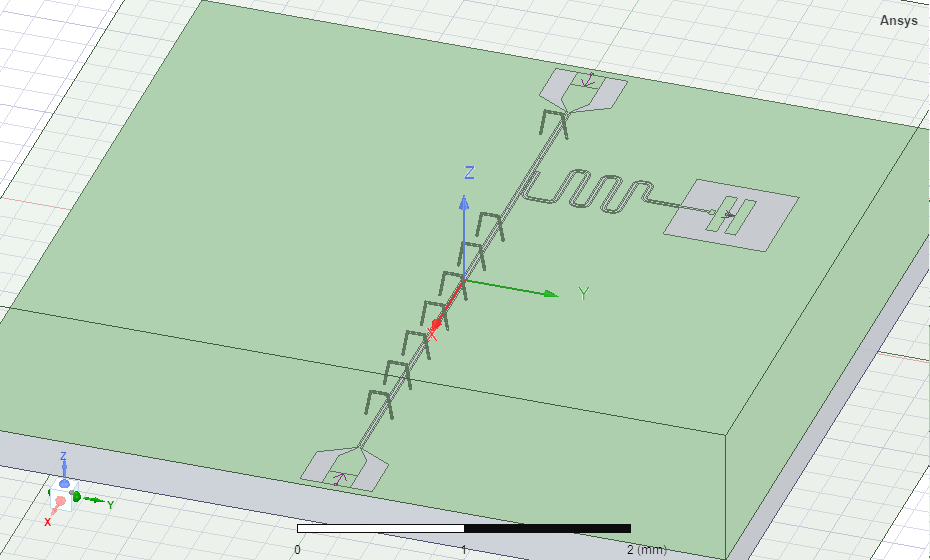

WindowsPath('C:/Users/Param/Documents/Projects/Frolov/GatemonAmrita/github/qiskit-metal/ansys.png')

In [9]:
hfss.clean_active_design()
hfss.activate_ansys_design("GM32_1",'eigenmode')  # use new_ansys_design() to force creation of a blank design
hfss.render_design(['Q1', 'ReadoutRes1', 'seg1','seg2','Q_Read1','LP2','LP1'], [], port_list=[('LP1', 'in','50'), ('LP2', 'in','50')], box_plus_buffer = False)
hfss.save_screenshot()



In [ ]:
# Analysis properties
setup = hfss.pinfo.setup
setup.n_modes = 2
setup.passes = 25
setup.min_converged=2
print(f"""
Number of eigenmodes to find             = {setup.n_modes}
Number of simulation passes              = {setup.passes}
Convergence freq max delta percent diff  = {setup.delta_f}
""")

pinfo = hfss.pinfo
pinfo.design.set_variable('Lj', '10 nH')
pinfo.design.set_variable('Cj', '0 fF')

setup.analyze()

INFO 11:01AM [analyze]: Analyzing setup Setup



Number of eigenmodes to find             = 2
Number of simulation passes              = 25
Convergence freq max delta percent diff  = 0.1



08:43PM 29s INFO [get_f_convergence]: Saved convergences to C:\Users\Param\Documents\Projects\Frolov\GatemonAmrita\github\qiskit-metal\hfss_eig_f_convergence.csv


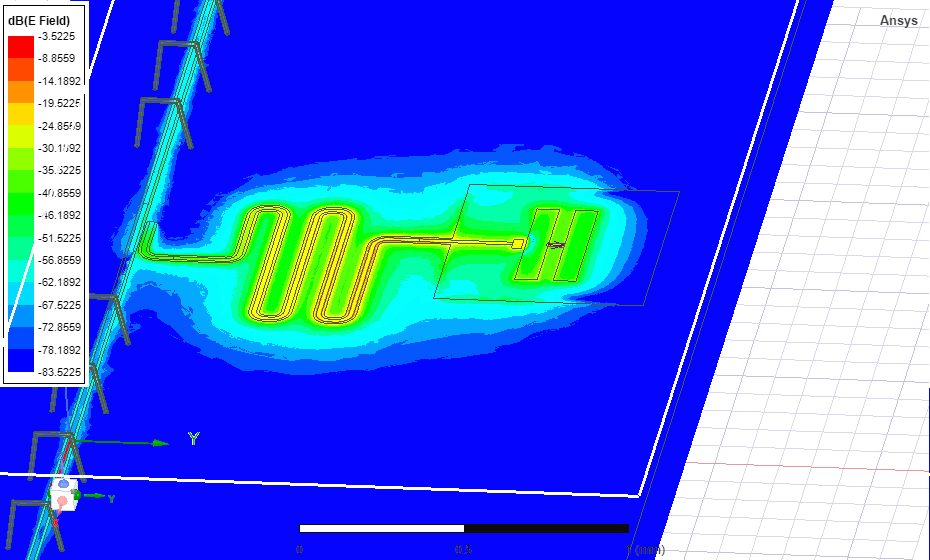

INFO 08:43PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)


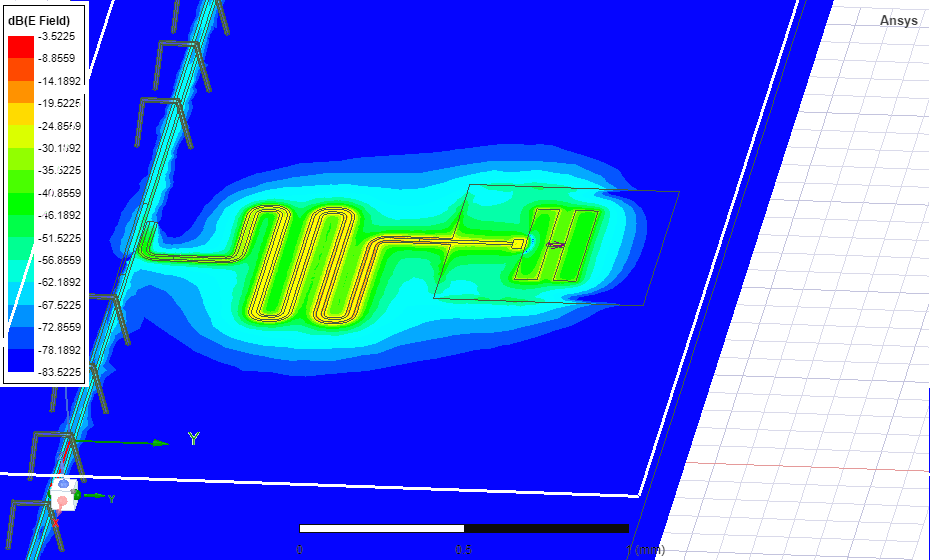

In [10]:
eig_qres.sim.convergence_t, eig_qres.sim.convergence_f, _ = hfss.get_convergences()
eig_qres.sim.plot_convergences()

hfss.modeler._modeler.ShowWindow()
hfss.plot_fields('main')
hfss.save_screenshot()
hfss.clear_fields(['Mag_E1'])
hfss.set_mode(2, "Setup")
hfss.modeler._modeler.ShowWindow()
hfss.plot_fields('main')
hfss.save_screenshot()
hfss.clear_fields(['Mag_E1'])

In [11]:


pinfo = hfss.pinfo
pinfo.junctions['jj'] = {'Lj_variable': 'Lj', 'rect': 'JJ_rect_Lj_Q1_rect_jj', 
                             'line': 'JJ_Lj_Q1_rect_jj_',  'Cj_variable': 'Cj'}
pinfo.validate_junction_info() # Check that valid names of variables and objects have been supplied
pinfo.dissipative['dielectrics_bulk'] = ['main'] # Dissipative elements: specify

eprd = epr.DistributedAnalysis(pinfo)

ℰ_elec = eprd.calc_energy_electric()
ℰ_elec_substrate = eprd.calc_energy_electric(None, 'main')
ℰ_mag = eprd.calc_energy_magnetic()

print(f"""
ℰ_elec_all       = {ℰ_elec}
ℰ_elec_substrate = {ℰ_elec_substrate}
EPR of substrate = {ℰ_elec_substrate / ℰ_elec * 100 :.1f}%

ℰ_mag_all       = {ℰ_mag}
ℰ_mag % of ℰ_elec_all  = {ℰ_mag / ℰ_elec * 100 :.1f}%
""")

eprd.do_EPR_analysis()

# 4a. Perform Hamiltonian spectrum post-analysis, building on mw solutions using EPR
epra = epr.QuantumAnalysis(eprd.data_filename)
epra.analyze_all_variations(cos_trunc = 8, fock_trunc = 7)

# 4b. Report solved results
swp_variable = 'Lj' # suppose we swept an optimetric analysis vs. inductance Lj_alice
epra.plot_hamiltonian_results(swp_variable=swp_variable)
epra.report_results(swp_variable=swp_variable, numeric=True)



Design "GM32_2" info:
	# eigenmodes    2
	# variations    1

ℰ_elec_all       = 7.24887954111154e-25
ℰ_elec_substrate = 6.67521516975972e-25
EPR of substrate = 92.1%

ℰ_mag_all       = 6.9553371474942e-25
ℰ_mag % of ℰ_elec_all  = 96.0%


Variation 0  [1/1]

  Mode 0 at 7.31 GHz   [1/2]
    Calculating ℰ_magnetic,ℰ_electric
       (ℰ_E-ℰ_H)/ℰ_E       ℰ_E       ℰ_H
               95.3%   1.16e-25 5.476e-27

    Calculating junction energy participation ration (EPR)
	method=`line_voltage`. First estimates:
	junction        EPR p_0j   sign s_0j    (p_capacitive)
		Energy fraction (Lj over Lj&Cj)= 95.96%
	jj               0.95136  (+)        0.0400922
		(U_tot_cap-U_tot_ind)/mean=2.04%
Calculating Qdielectric_main for mode 0 (0/1)
p_dielectric_main_0 = 0.9213210757366322

  Mode 1 at 8.03 GHz   [2/2]
    Calculating ℰ_magnetic,ℰ_electric
       (ℰ_E-ℰ_H)/ℰ_E       ℰ_E       ℰ_H
                4.0%  3.624e-25 3.478e-25

    Calculating junction energy participation ration (EPR)
	method=`lin

WARNING 08:45PM [__init__]: <p>Error: <class 'IndexError'></p>



ANALYSIS DONE. Data saved to:

C:\data-pyEPR\Project1\GM32_2\2023-06-22 20-43-56.npz


	 Differences in variations:



 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
Variation 0

Starting the diagonalization
Finished the diagonalization
Pm_norm=
modes
0    1.042626
1    1.027311
dtype: float64

Pm_norm idx =
      jj
0   True
1  False
*** P (participation matrix, not normlz.)
         jj
0  0.914688
1  0.040352

*** S (sign-bit matrix)
   s_jj
0     1
1    -1
*** P (participation matrix, normalized.)
      0.95
      0.04

*** Chi matrix O1 PT (MHz)
    Diag is anharmonicity, off diag is full cross-Kerr.
       371     34.5
      34.5    0.804

*** Chi matrix ND (MHz) 
       450     11.7
      11.7    0.122

*** Frequencies O1 PT (MHz)
0    6917.231526
1    8015.796237
dtype: float64

*** Frequencies ND (MHz)
0    6885.524866
1    8021.675615
dtype: float64

*** Q_coupling
Empty DataFrame
Columns: []
Index: [0, 1]


#### Mode frequencies (MHz)

###### Numerical diagonalization

Lj,10
0,6885.52
1,8021.68


#### Kerr Non-linear coefficient table (MHz)

###### Numerical diagonalization

0      1
Lj                 
10 0  449.83  11.73
   1   11.73   0.12

ocuments\Projectsrolov\GatemonAmrita\github\qiskit-metal\qiskit_metal\_gui\styles\metal_dark\rc\transparent.pngfrom C:\Users\Param

ocuments\Projectsrolov\GatemonAmrita\github\qiskit-metal\qiskit_metal\_gui\styles\metal_dark\rc\transparent.pngfrom C:\Users\Param

ocuments\Projectsrolov\GatemonAmrita\github\qiskit-metal\qiskit_metal\_gui\styles\metal_dark\rc\transparent.pngfrom C:\Users\Param

ocuments\Projectsrolov\GatemonAmrita\github\qiskit-metal\qiskit_metal\_gui\styles\metal_dark\rc\transparent.pngfrom C:\Users\Param

ocuments\Projectsrolov\GatemonAmrita\github\qiskit-metal\qiskit_metal\_gui\styles\metal_dark\rc\transparent.pngfrom C:\Users\Param

ocuments\Projectsrolov\GatemonAmrita\github\qiskit-metal\qiskit_metal\_gui\styles\metal_dark\rc\transparent.pngfrom C:\Users\Param

ocuments\Projectsrolov\GatemonAmrita\github\qiskit-metal\qiskit_metal\_gui\styles\metal_dark\rc\transparent.pngfrom C:\Users\Param

ocuments\Projectsrolov\GatemonAmrita\github\qiskit-metal\qiskit_meta

In [43]:
eig_qres.sim.close()

Warning! 6 COM references still alive
Ansys will likely refuse to shut down
